In [ ]:
#@title Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [ ]:
#@title Load Clean Financial Data

income_df = pd.read_csv("income_statement.csv")

balance_df = pd.read_csv("balance_sheet.csv")

cashflow_df = pd.read_csv("cash_flow.csv")

In [ ]:
#@title Preview Datasets

display(income_df)

display(balance_df)

display(cashflow_df)

,Year,Revenue,Operating_Expenses,Operating_Profit,Other_Income,Depreciation,Interest,PBT,Tax,Net_Income,EPS
0,2017,"68,484.00","49,880.00","18,604.00","3,050.00","1,703.00",0.00,"19,951.00","5,598.00","14,353.00",31.24
1,2018,"70,522.00","51,700.00","18,822.00","3,311.00","1,863.00",0.00,"20,270.00","4,241.00","16,029.00",36.69
2,2019,"82,675.00","62,505.00","20,170.00","2,882.00","2,011.00",0.00,"21,041.00","5,631.00","15,404.00",35.26
3,2020,"90,791.00","68,524.00","22,267.00","2,803.00","2,893.00",170.00,"22,007.00","5,368.00","16,594.00",38.96
4,2021,"100,472.00","72,583.00","27,889.00","2,201.00","3,267.00",195.00,"26,628.00","7,205.00","19,351.00",45.42
5,2022,"121,641.00","90,150.00","31,491.00","2,295.00","3,476.00",200.00,"30,110.00","7,964.00","22,110.00",52.56
6,2023,"146,767.00","111,637.00","35,130.00","2,701.00","4,225.00",284.00,"33,322.00","9,214.00","24,095.00",58.08
7,2024,"153,670.00","117,245.00","36,425.00","4,711.00","4,678.00",470.00,"35,988.00","9,740.00","26,233.00",63.20
8,2025,"162,990.00","123,754.00","39,236.00","3,600.00","4,812.00",416.00,"37,608.00","10,858.00","26,713.00",64.32
9,2026,"178,650.00","136,370.00","42,280.00","3,033.00","4,902.00",416.00,"39,995.00","10,521.00","29,440.00",72.59


,Year,Share_Capital,Reserves,Borrowings,Other_Liabilities,Total_Assets,Net_Block,CWIP,Investments,Other_Assets,Working_Capital,Receivables
0,2017,"1,144.00","67,838.00",0.00,"14,166.00","83,148.00","14,179.00","1,365.00","16,423.00","51,181.00","37,015.00","12,322.00"
1,2018,"1,088.00","63,835.00",0.00,"14,426.00","79,349.00","12,574.00","1,606.00","12,163.00","53,006.00","38,580.00","13,142.00"
2,2019,"2,170.00","62,778.00",0.00,"19,118.00","84,066.00","15,710.00","1,388.00","11,261.00","55,707.00","36,589.00","14,827.00"
3,2020,"2,122.00","63,328.00","4,633.00","21,717.00","91,800.00","23,789.00",954.00,"8,792.00","58,265.00","36,548.00","18,487.00"
4,2021,"2,124.00","74,227.00","5,325.00","25,835.00","107,511.00","25,505.00",922.00,"14,205.00","66,879.00","41,044.00","19,294.00"
5,2022,"2,098.00","73,252.00","5,474.00","35,905.00","116,729.00","25,800.00",416.00,"20,324.00","70,189.00","34,284.00","22,698.00"
6,2023,"2,069.00","73,338.00","8,299.00","40,890.00","124,596.00","29,225.00",288.00,"19,478.00","75,605.00","34,715.00","25,424.00"
7,2024,"2,071.00","86,045.00","8,359.00","39,545.00","136,020.00","27,622.00",293.00,"24,623.00","83,482.00","43,937.00","30,193.00"
8,2025,"2,073.00","93,745.00","8,227.00","43,750.00","147,795.00","30,961.00",814.00,"23,541.00","92,479.00","48,729.00","31,158.00"
9,2026,"2,024.00","90,828.00","9,176.00","52,260.00","154,288.00","33,770.00",526.00,"21,880.00","98,112.00","45,852.00","35,234.00"


,Year,Operating_CF,Investing_CF,Financing_CF,Net_CF
0,2017,11531,-14664,-6939,-10072
1,2018,13218,4533,-20505,-2754
2,2019,14841,-632,-14512,-303
3,2020,17003,-331,-17591,-919
4,2021,23224,-7373,-9786,6065
5,2022,23885,-6485,-24642,-7242
6,2023,22467,-1071,-26695,-5299
7,2024,25210,-5093,-17504,2613
8,2025,35694,-1864,-24161,9669
9,2026,33986,3546,-39786,-2254


In [ ]:
#@title Create Master Financial Dataset

financials = pd.DataFrame({

    "Year": income_df["Year"],

    "Revenue": income_df["Revenue"],

    "Operating_Profit": income_df["Operating_Profit"],

    "PBT": income_df["PBT"],

    "Net_Income": income_df["Net_Income"],

    "EPS": income_df["EPS"],

    "Operating_CF": cashflow_df["Operating_CF"],

    "Borrowings": balance_df["Borrowings"],

    "Working_Capital": balance_df["Working_Capital"],

    "Investments": balance_df["Investments"],

    "Total_Assets": balance_df["Total_Assets"]

})

financials

,Year,Revenue,Operating_Profit,PBT,Net_Income,EPS,Operating_CF,Borrowings,Working_Capital,Investments,Total_Assets
0,2017,"68,484.00","18,604.00","19,951.00","14,353.00",31.24,11531,0.00,"37,015.00","16,423.00","83,148.00"
1,2018,"70,522.00","18,822.00","20,270.00","16,029.00",36.69,13218,0.00,"38,580.00","12,163.00","79,349.00"
2,2019,"82,675.00","20,170.00","21,041.00","15,404.00",35.26,14841,0.00,"36,589.00","11,261.00","84,066.00"
3,2020,"90,791.00","22,267.00","22,007.00","16,594.00",38.96,17003,"4,633.00","36,548.00","8,792.00","91,800.00"
4,2021,"100,472.00","27,889.00","26,628.00","19,351.00",45.42,23224,"5,325.00","41,044.00","14,205.00","107,511.00"
5,2022,"121,641.00","31,491.00","30,110.00","22,110.00",52.56,23885,"5,474.00","34,284.00","20,324.00","116,729.00"
6,2023,"146,767.00","35,130.00","33,322.00","24,095.00",58.08,22467,"8,299.00","34,715.00","19,478.00","124,596.00"
7,2024,"153,670.00","36,425.00","35,988.00","26,233.00",63.20,25210,"8,359.00","43,937.00","24,623.00","136,020.00"
8,2025,"162,990.00","39,236.00","37,608.00","26,713.00",64.32,35694,"8,227.00","48,729.00","23,541.00","147,795.00"
9,2026,"178,650.00","42,280.00","39,995.00","29,440.00",72.59,33986,"9,176.00","45,852.00","21,880.00","154,288.00"


In [ ]:
#@title Dataset Information

financials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              10 non-null     int64  
 1   Revenue           10 non-null     float64
 2   Operating_Profit  10 non-null     float64
 3   PBT               10 non-null     float64
 4   Net_Income        10 non-null     float64
 5   EPS               10 non-null     float64
 6   Operating_CF      10 non-null     int64  
 7   Borrowings        10 non-null     float64
 8   Working_Capital   10 non-null     float64
 9   Investments       10 non-null     float64
 10  Total_Assets      10 non-null     float64
dtypes: float64(9), int64(2)
memory usage: 1012.0 bytes


In [ ]:
#@title Missing Values

financials.isna().sum()

,0
Year,0
Revenue,0
Operating_Profit,0
PBT,0
Net_Income,0
EPS,0
Operating_CF,0
Borrowings,0
Working_Capital,0
Investments,0


#Year Over Year Growth

In [ ]:
#@title Revenue Growth

financials["Revenue_Growth_%"] = (
    financials["Revenue"]
    .pct_change()
    * 100
)

financials[["Year","Revenue","Revenue_Growth_%"]]

,Year,Revenue,Revenue_Growth_%
0,2017,"68,484.00",NaN
1,2018,"70,522.00",2.98
2,2019,"82,675.00",17.23
3,2020,"90,791.00",9.82
4,2021,"100,472.00",10.66
5,2022,"121,641.00",21.07
6,2023,"146,767.00",20.66
7,2024,"153,670.00",4.70
8,2025,"162,990.00",6.06
9,2026,"178,650.00",9.61


In [ ]:
#@title Operating Profit Growth

financials["Operating_Profit_Growth_%"] = (
    financials["Operating_Profit"]
    .pct_change()
    * 100
)

financials[["Year","Operating_Profit","Operating_Profit_Growth_%"]]

,Year,Operating_Profit,Operating_Profit_Growth_%
0,2017,"18,604.00",NaN
1,2018,"18,822.00",1.17
2,2019,"20,170.00",7.16
3,2020,"22,267.00",10.40
4,2021,"27,889.00",25.25
5,2022,"31,491.00",12.92
6,2023,"35,130.00",11.56
7,2024,"36,425.00",3.69
8,2025,"39,236.00",7.72
9,2026,"42,280.00",7.76


In [ ]:
#@title Net Income Growth

financials["Net_Income_Growth_%"] = (
    financials["Net_Income"]
    .pct_change()
    * 100
)

financials[["Year","Net_Income","Net_Income_Growth_%"]]

,Year,Net_Income,Net_Income_Growth_%
0,2017,"14,353.00",NaN
1,2018,"16,029.00",11.68
2,2019,"15,404.00",-3.90
3,2020,"16,594.00",7.73
4,2021,"19,351.00",16.61
5,2022,"22,110.00",14.26
6,2023,"24,095.00",8.98
7,2024,"26,233.00",8.87
8,2025,"26,713.00",1.83
9,2026,"29,440.00",10.21


In [ ]:
#@title Operating Cash Flow Growth

financials["Operating_CF_Growth_%"] = (
    financials["Operating_CF"]
    .pct_change()
    * 100
)

financials[["Year","Operating_CF","Operating_CF_Growth_%"]]

,Year,Operating_CF,Operating_CF_Growth_%
0,2017,11531,NaN
1,2018,13218,14.63
2,2019,14841,12.28
3,2020,17003,14.57
4,2021,23224,36.59
5,2022,23885,2.85
6,2023,22467,-5.94
7,2024,25210,12.21
8,2025,35694,41.59
9,2026,33986,-4.79


#CAGR

In [ ]:
#@title Revenue CAGR

years = len(financials)-1

revenue_cagr = (
    (
        financials["Revenue"].iloc[-1] /
        financials["Revenue"].iloc[0]
    )**(1/years)-1
)*100

print(f"Revenue CAGR : {revenue_cagr:.2f}%")

Revenue CAGR : 11.24%


In [ ]:
#@title Operating Profit CAGR

op_cagr = (
    (
        financials["Operating_Profit"].iloc[-1] /
        financials["Operating_Profit"].iloc[0]
    )**(1/years)-1
)*100

print(f"Operating Profit CAGR : {op_cagr:.2f}%")

Operating Profit CAGR : 9.55%


In [ ]:
#@title Net Income CAGR

profit_cagr = (
    (
        financials["Net_Income"].iloc[-1] /
        financials["Net_Income"].iloc[0]
    )**(1/years)-1
)*100

print(f"Net Income CAGR : {profit_cagr:.2f}%")

Net Income CAGR : 8.31%


#Margin Analysis

In [ ]:
#@title Operating Margin

financials["Operating_Margin_%"] = (
    financials["Operating_Profit"] /
    financials["Revenue"]
)*100

financials[["Year","Operating_Margin_%"]]

,Year,Operating_Margin_%
0,2017,27.17
1,2018,26.69
2,2019,24.40
3,2020,24.53
4,2021,27.76
5,2022,25.89
6,2023,23.94
7,2024,23.70
8,2025,24.07
9,2026,23.67


In [ ]:
#@title Net Profit Margin

financials["Net_Margin_%"] = (
    financials["Net_Income"] /
    financials["Revenue"]
)*100

financials[["Year","Net_Margin_%"]]

,Year,Net_Margin_%
0,2017,20.96
1,2018,22.73
2,2019,18.63
3,2020,18.28
4,2021,19.26
5,2022,18.18
6,2023,16.42
7,2024,17.07
8,2025,16.39
9,2026,16.48


In [ ]:
#@title Operating Cash Flow Margin

financials["Operating_CF_Margin_%"] = (
    financials["Operating_CF"] /
    financials["Revenue"]
)*100

financials[["Year","Operating_CF_Margin_%"]]

,Year,Operating_CF_Margin_%
0,2017,16.84
1,2018,18.74
2,2019,17.95
3,2020,18.73
4,2021,23.11
5,2022,19.64
6,2023,15.31
7,2024,16.41
8,2025,21.90
9,2026,19.02


#Historical Trend Analysis

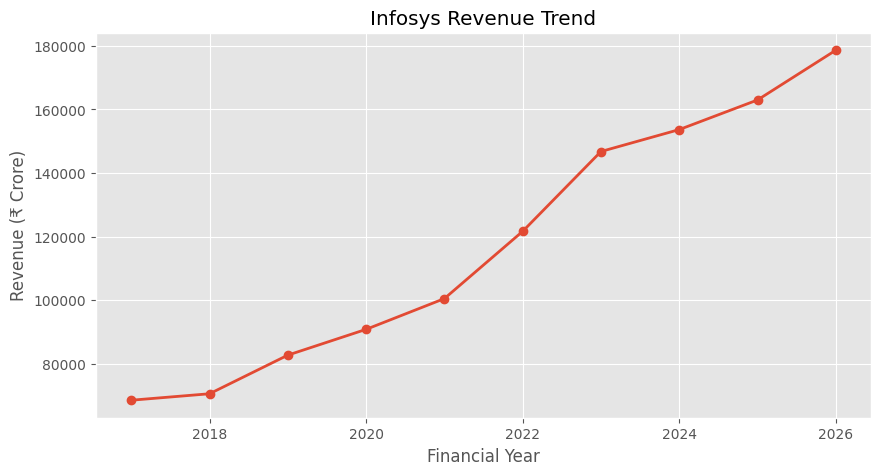

In [ ]:
#@title Revenue Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Infosys Revenue Trend")
plt.xlabel("Financial Year")
plt.ylabel("Revenue (₹ Crore)")

plt.grid(True)

plt.show()

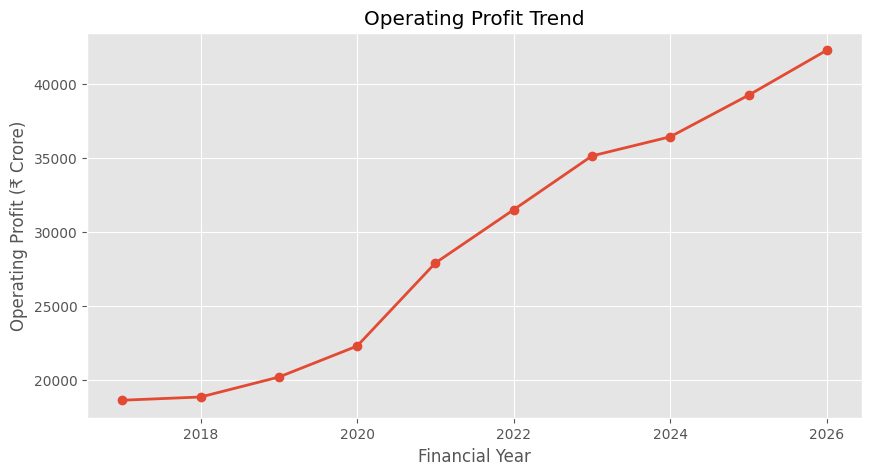

In [ ]:
#@title Operating Profit Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Operating_Profit"],
    marker="o",
    linewidth=2
)

plt.title("Operating Profit Trend")
plt.xlabel("Financial Year")
plt.ylabel("Operating Profit (₹ Crore)")

plt.grid(True)

plt.show()

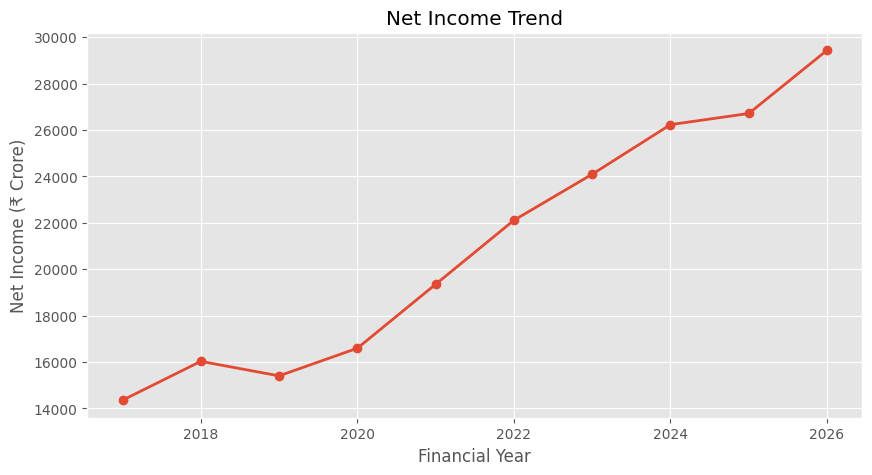

In [ ]:
#@title Net Income Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Net_Income"],
    marker="o",
    linewidth=2
)

plt.title("Net Income Trend")
plt.xlabel("Financial Year")
plt.ylabel("Net Income (₹ Crore)")

plt.grid(True)

plt.show()

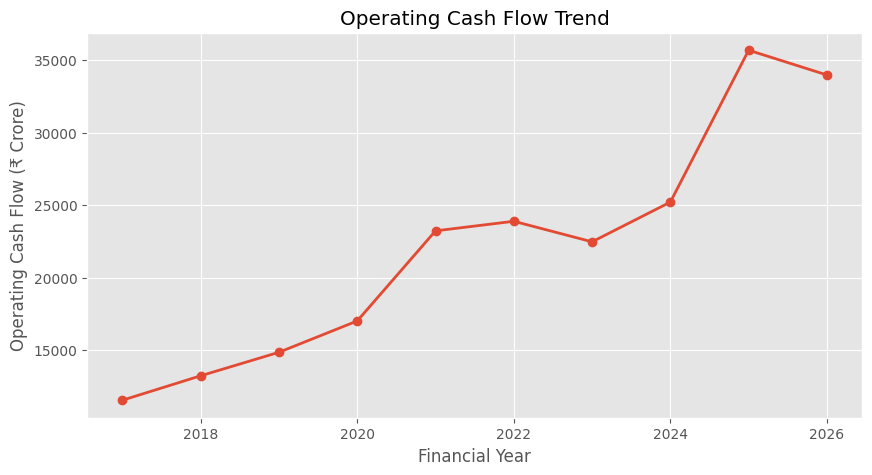

In [ ]:
#@title Operating Cash Flow Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Operating_CF"],
    marker="o",
    linewidth=2
)

plt.title("Operating Cash Flow Trend")
plt.xlabel("Financial Year")
plt.ylabel("Operating Cash Flow (₹ Crore)")

plt.grid(True)

plt.show()

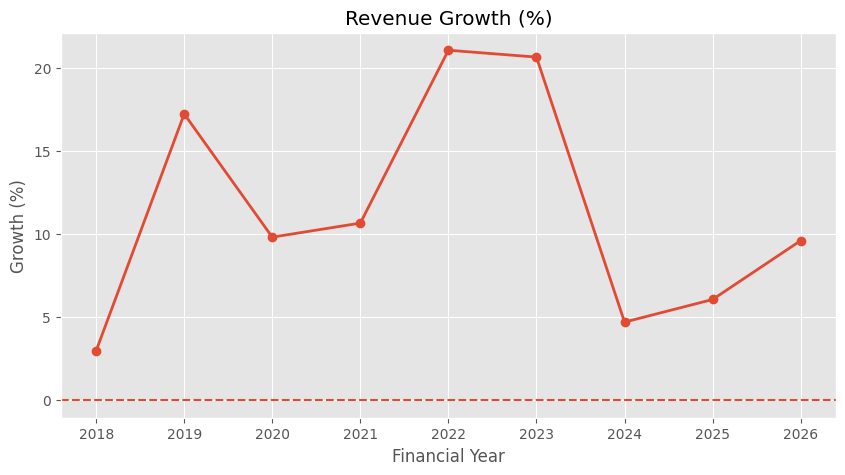

In [ ]:
#@title Revenue Growth Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Revenue_Growth_%"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--")

plt.title("Revenue Growth (%)")
plt.xlabel("Financial Year")
plt.ylabel("Growth (%)")

plt.grid(True)

plt.show()

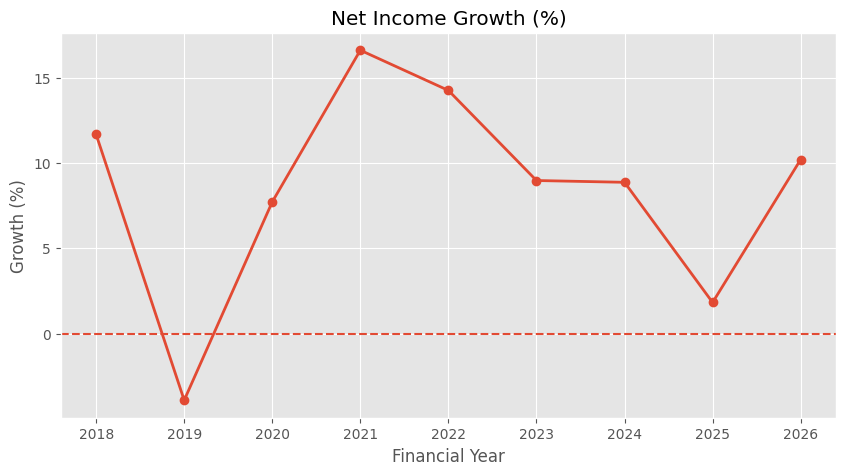

In [ ]:
#@title Net Income Growth Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Net_Income_Growth_%"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--")

plt.title("Net Income Growth (%)")
plt.xlabel("Financial Year")
plt.ylabel("Growth (%)")

plt.grid(True)

plt.show()

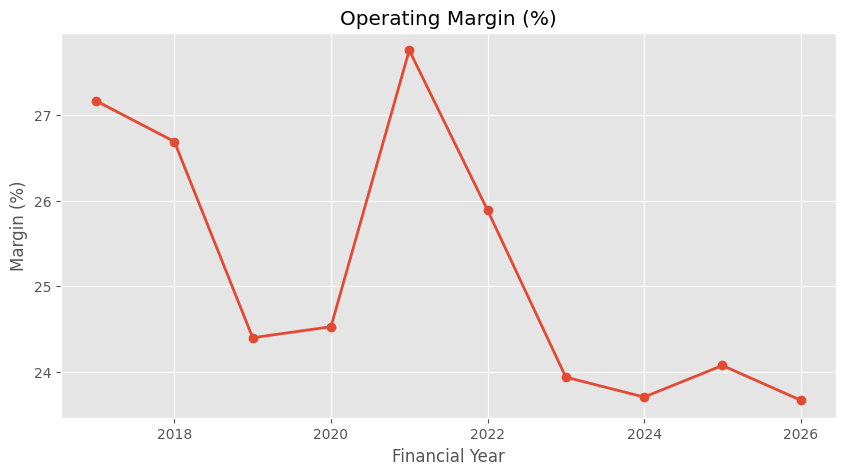

In [ ]:
#@title Operating Margin Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Operating_Margin_%"],
    marker="o",
    linewidth=2
)

plt.title("Operating Margin (%)")
plt.xlabel("Financial Year")
plt.ylabel("Margin (%)")

plt.grid(True)

plt.show()

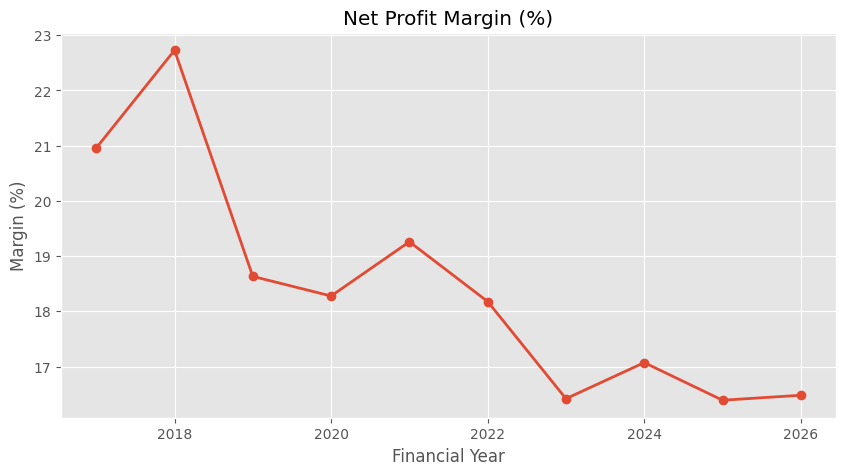

In [ ]:
#@title Net Margin Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Net_Margin_%"],
    marker="o",
    linewidth=2
)

plt.title("Net Profit Margin (%)")
plt.xlabel("Financial Year")
plt.ylabel("Margin (%)")

plt.grid(True)

plt.show()

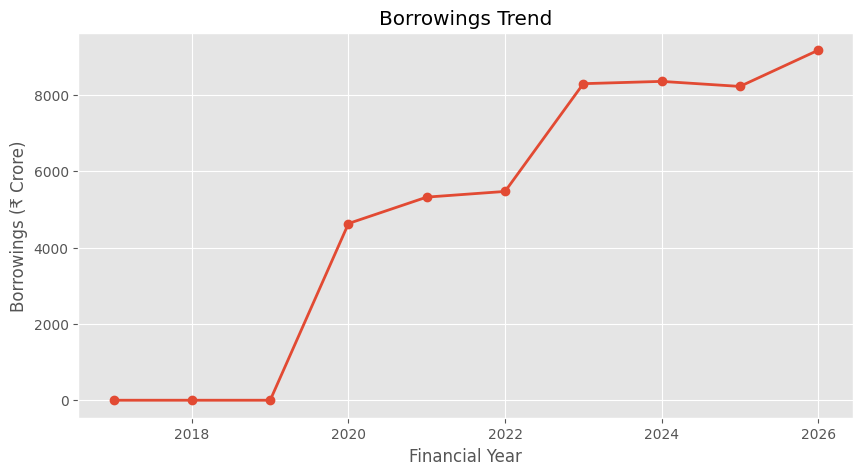

In [ ]:
#@title Borrowings Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Borrowings"],
    marker="o",
    linewidth=2
)

plt.title("Borrowings Trend")
plt.xlabel("Financial Year")
plt.ylabel("Borrowings (₹ Crore)")

plt.grid(True)

plt.show()

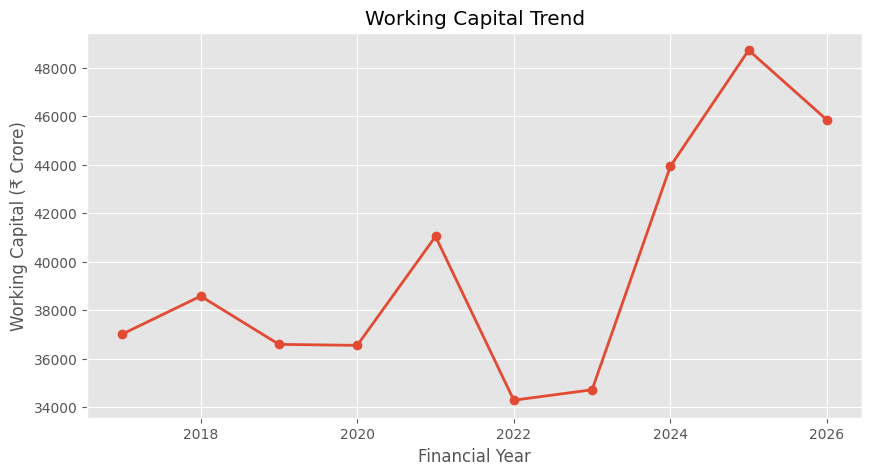

In [ ]:
#@title Working Capital Trend

plt.figure(figsize=(10,5))

plt.plot(
    financials["Year"],
    financials["Working_Capital"],
    marker="o",
    linewidth=2
)

plt.title("Working Capital Trend")
plt.xlabel("Financial Year")
plt.ylabel("Working Capital (₹ Crore)")

plt.grid(True)

plt.show()

In [ ]:
#@title Historical Performance Summary

summary = pd.DataFrame({

    "Metric": [

        "Revenue CAGR (%)",

        "Operating Profit CAGR (%)",

        "Net Income CAGR (%)",

        "Average Operating Margin (%)",

        "Average Net Margin (%)",

        "Average Operating CF Margin (%)"

    ],

    "Value":[

        revenue_cagr,

        op_cagr,

        profit_cagr,

        financials["Operating_Margin_%"].mean(),

        financials["Net_Margin_%"].mean(),

        financials["Operating_CF_Margin_%"].mean()

    ]

})

summary["Value"] = summary["Value"].round(2)

summary

,Metric,Value
0,Revenue CAGR (%),11.24
1,Operating Profit CAGR (%),9.55
2,Net Income CAGR (%),8.31
3,Average Operating Margin (%),25.18
4,Average Net Margin (%),18.44
5,Average Operating CF Margin (%),18.76
